Train accuracy: 0.9985122243013589
Test accuracy: 0.9955981820133843


NameError: name 'label_col' is not defined

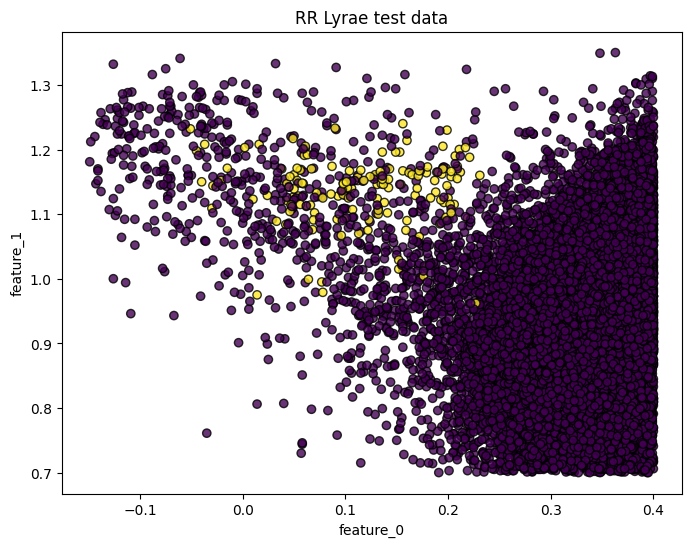

In [6]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from astroML.datasets import fetch_rrlyrae_combined
from astroML.utils import split_samples
import numpy as np
import matplotlib.pyplot as plt
X, y = fetch_rrlyrae_combined()
X = X[:, [1, 0, 2, 3]]  # rearrange columns for better 1-color results
(X_train, X_test), (y_train, y_test) = split_samples(X, y, [0.75, 0.25],
                                                     random_state=0)


if X.shape[1] == 0:
    raise ValueError("No numeric features found in the dataset. Please check the loaded RR Lyrae data.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf = DecisionTreeClassifier(criterion='gini', min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

print("Train accuracy:", clf.score(X_train, y_train))
print("Test accuracy:", clf.score(X_test, y_test))

numeric_features = [f"feature_{i}" for i in range(X.shape[1])]
if len(numeric_features) >= 2:
    y_test_codes = pd.Categorical(y_test).codes
    class_names = pd.Categorical(y_test).categories

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        X_test[:, 0],
        X_test[:, 1],
        c=y_test_codes,
        cmap='viridis',
        alpha=0.8,
        edgecolor='k'
    )
    plt.xlabel(numeric_features[0])
    plt.ylabel(numeric_features[1])
    plt.title('RR Lyrae test data')
    handles, labels = scatter.legend_elements()
    plt.legend(handles, class_names, title=label_col)
    plt.show()

plt.figure(figsize=(16, 10))
plot_tree(
    clf,
    feature_names=numeric_features,
    class_names=[str(c) for c in clf.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree for RR Lyrae')
plt.show()

completeness [0.01459854 0.27007299 0.4379562  0.49635036]
contamination [0.81818182 0.47887324 0.34782609 0.32      ]


C:\Users\annat\AppData\Local\Temp\ipykernel_20628\1891860723.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right',


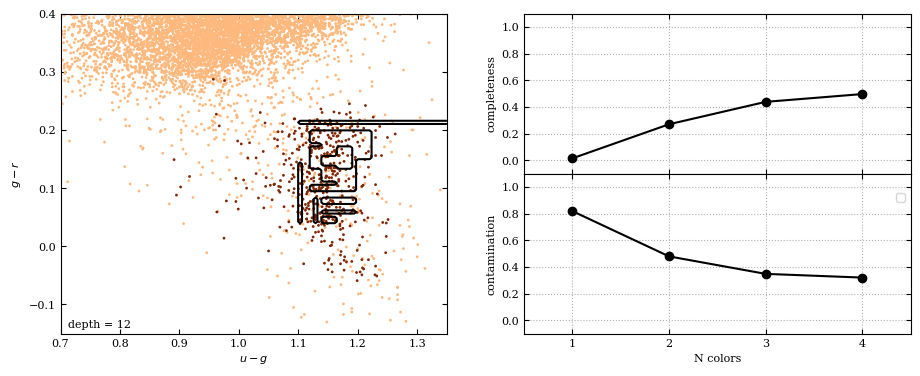

In [14]:
from sklearn.tree import DecisionTreeClassifier
from astroML.datasets import fetch_rrlyrae_combined
from astroML.utils import split_samples
from astroML.utils import completeness_contamination

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#----------------------------------------------------------------------
# get data and split into training & testing sets
X, y = fetch_rrlyrae_combined()
X = X[:, [1, 0, 2, 3]]  # rearrange columns for better 1-color results
(X_train, X_test), (y_train, y_test) = split_samples(X, y, [0.75, 0.25],
                                                     random_state=0)
N_tot = len(y)
N_st = np.sum(y == 0)
N_rr = N_tot - N_st
N_train = len(y_train)
N_test = len(y_test)
N_plot = 5000 + N_rr

#----------------------------------------------------------------------
# Fit Decision tree
Ncolors = np.arange(1, X.shape[1] + 1)

classifiers = []
predictions = []
Ncolors = np.arange(1, X.shape[1] + 1)
depths = [7, 12]

for nc in Ncolors:
    clf = DecisionTreeClassifier(criterion='gini', min_samples_leaf=8, random_state=42)
    clf.fit(X_train[:, :nc], y_train)
    y_pred = clf.predict(X_test[:, :nc])

    classifiers.append(clf)
    predictions.append(y_pred)

completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)

#------------------------------------------------------------
# compute the decision boundary

clf = classifiers
xlim = (0.7, 1.35)
ylim = (-0.15, 0.4)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 101),
                     np.linspace(ylim[0], ylim[1], 101))

# use the classifier trained with 2 colors (index 1) so predict expects 2 features
Z = classifiers[1].predict(np.c_[yy.ravel(), xx.ravel()])
Z = Z.reshape(xx.shape)

# plot the results
fig = plt.figure(figsize=(10, 4))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

ax.contour(xx, yy, Z, [0.5], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')

ax.text(0.02, 0.02, "depth = %i" % depths[1],
        transform=ax.transAxes)

# plot completeness vs Ncolors
ax = fig.add_subplot(222)
ax.plot(Ncolors, completeness, 'o-k', ms=6)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

# plot contamination vs Ncolors
ax = fig.add_subplot(224)
ax.plot(Ncolors, contamination, 'o-k', ms=6)
ax.legend(loc='lower right',
          bbox_to_anchor=(1.0, 0.79))
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))

ax.set_xlabel('N colors')
ax.set_ylabel('contamination')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

plt.show()